# Synthetic dictionary-learning demo

Select the project's **Python (gene-complexity)** kernel and **Run All**. Install the root `requirements.txt` first if needed.

This notebook runs the shared implementation in `synthetic_demo.py`, then inspects the saved artifacts. The toy data represent signed, processed expression features—not raw counts or a biological benchmark. Each run writes to a new directory so rerunning cells preserves previous results.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
from uuid import uuid4
import importlib.util
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts at the repository root or in code/dict-learn/.
root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "code/dict-learn/synthetic_demo.py").is_file()), None)
if root is None:
    raise RuntimeError("Open this notebook from within the gene-complexity repository.")
module_path = root / "code/dict-learn/synthetic_demo.py"
spec = importlib.util.spec_from_file_location("dictionary_synthetic_demo", module_path)
demo = importlib.util.module_from_spec(spec)
spec.loader.exec_module(demo)
print("Python:", sys.executable)
print("Project:", root)


Python: /Users/jonathanma/Desktop/Projects/gene-complexity/.venv/bin/python
Project: /Users/jonathanma/Desktop/Projects/gene-complexity


## Generate, fit, and export

The shared demo generates 240 cells × 40 genes from eight atoms, using two generating coefficients per cell plus noise. It splits 160/40/40 cells into training/validation/test sets. Only training cells determine the centering mean and dictionary. All cells are then encoded using the fixed dictionary and a Lasso penalty of 0.1.

The run checks finite codes, atom norms, unchanged dictionary during encoding, reconstruction against zero, and export/reload consistency. No labels or classifier are involved.


In [2]:
SEED = 42
run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S") + "_" + uuid4().hex[:8]
output_dir = root / "results/dict-learning" / f"notebook_seed{SEED}_{run_id}"
demo.run(output_dir, seed=SEED)


{
  "train": {
    "n_cells": 160,
    "mse": 0.0022727752002232927,
    "zero_reconstruction_mse": 0.2065124347995085,
    "active_fraction": 0.48203125
  },
  "validation": {
    "n_cells": 40,
    "mse": 0.0025886419266644744,
    "zero_reconstruction_mse": 0.20853547843904027,
    "active_fraction": 0.490625
  },
  "test": {
    "n_cells": 40,
    "mse": 0.0025795884781466593,
    "zero_reconstruction_mse": 0.22740578486519447,
    "active_fraction": 0.509375
  }
}
Checks passed. Artifacts: /Users/jonathanma/Desktop/Projects/gene-complexity/results/dict-learning/notebook_seed42_20261007T160300_f7dcaf31


## Inspect the data and learned representation

Rows retain the original cell order. Gene columns retain their recorded order.


In [3]:
def read_arrays(path):
    with np.load(path, allow_pickle=False) as archive:
        return {key: archive[key] for key in archive.files}

data = read_arrays(output_dir / "synthetic_data.npz")
fitted = read_arrays(output_dir / "dictionary.npz")
codes = read_arrays(output_dir / "codes.npz")
report = json.loads((output_dir / "metrics.json").read_text())
np.testing.assert_array_equal(codes["cell_ids"], data["cell_ids"])
np.testing.assert_array_equal(fitted["gene_ids"], data["gene_ids"])
print("Expression:", data["X"].shape)
print("Dictionary:", fitted["dictionary"].shape)
print("Codes:", codes["vectors"].shape)
display(pd.DataFrame(data["X"][:5, :8], index=data["cell_ids"][:5],
                     columns=data["gene_ids"][:8]))
display(pd.DataFrame(codes["vectors"][:5], index=codes["cell_ids"][:5],
                     columns=[f"atom_{i}" for i in range(codes["vectors"].shape[1])]))


Expression: (240, 40)
Dictionary: (8, 40)
Codes: (240, 8)


,synthetic_gene_000,synthetic_gene_001,synthetic_gene_002,synthetic_gene_003,synthetic_gene_004,synthetic_gene_005,synthetic_gene_006,synthetic_gene_007
synthetic_cell_0000,-0.284559,-0.052426,0.811900,-0.173987,-0.058533,-0.341361,0.197067,-0.042933
synthetic_cell_0001,0.328763,-0.385616,0.003471,0.673190,-1.197587,-0.501435,-0.098894,-0.257352
synthetic_cell_0002,0.526460,-0.690847,1.091312,0.739713,-1.194329,0.298299,0.577998,-0.665162
synthetic_cell_0003,0.242880,0.564579,-0.965005,0.180782,-0.085777,0.385210,-0.369325,-0.186145
synthetic_cell_0004,0.669197,0.174627,-0.768155,-0.121992,-0.517870,0.172084,-0.781348,0.246938


,atom_0,atom_1,atom_2,atom_3,atom_4,atom_5,atom_6,atom_7
synthetic_cell_0000,-0.000000,0.106047,2.055526,0.000000,0.000000,-0.000000,-0.929599,0.000000
synthetic_cell_0001,-0.025078,-2.602011,-1.249341,-0.000000,0.000000,-0.000000,0.000000,0.000000
synthetic_cell_0002,-0.412202,0.173787,-0.000000,0.000000,2.657027,-0.000000,0.094375,2.614904
synthetic_cell_0003,-0.164676,0.085655,-2.052768,-0.000000,-1.079225,-0.012368,-0.000000,0.000000
synthetic_cell_0004,-0.304033,0.105052,-1.974757,1.878526,0.000000,-0.000000,0.000000,0.000000


## Reconstruction and sparsity

The zero baseline reconstructs the centered matrix with zeros, equivalent to predicting the training mean in the original feature space. `active_fraction` counts coefficients above magnitude 1e-6. These metrics check this synthetic example; they do not measure biological classification quality.


,n_cells,mse,zero_reconstruction_mse,active_fraction
train,160,0.002273,0.206512,0.482031
validation,40,0.002589,0.208535,0.490625
test,40,0.002580,0.227406,0.509375


Fit iterations: 120
Reached iteration budget: False


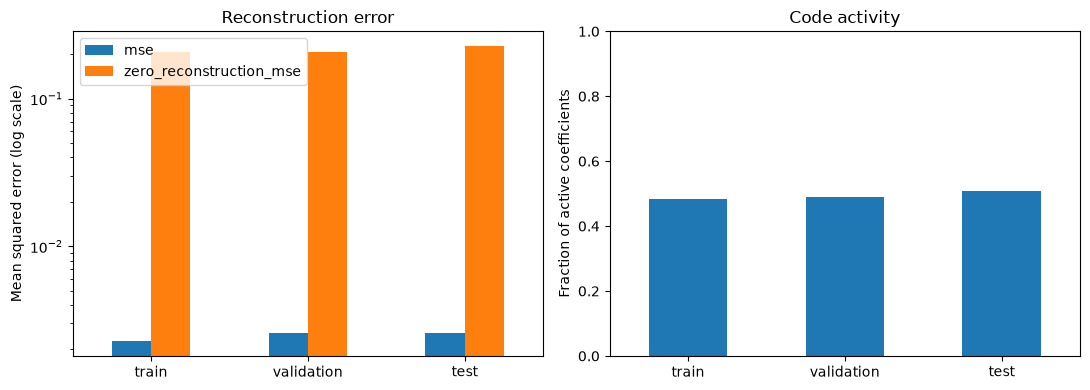

In [4]:
metrics = pd.DataFrame.from_dict(report["metrics"], orient="index")
display(metrics)
print("Fit iterations:", report["iterations"])
print("Reached iteration budget:", report["reached_iteration_budget"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metrics[["mse", "zero_reconstruction_mse"]].plot.bar(ax=axes[0], rot=0, logy=True)
axes[0].set(title="Reconstruction error", ylabel="Mean squared error (log scale)")
metrics["active_fraction"].plot.bar(ax=axes[1], rot=0)
axes[1].set(title="Code activity", ylabel="Fraction of active coefficients", ylim=(0, 1))
fig.tight_layout()
plt.show()


## Learned atoms and optimization

Atom signs and ordering are not identifiable, so this heatmap is not an elementwise recovery comparison with the generating dictionary. Lower training objective does not guarantee more useful biological programs.


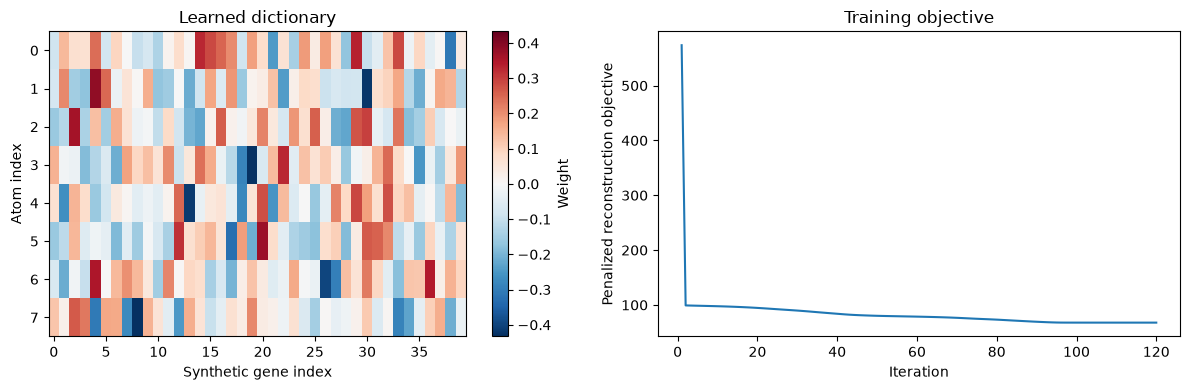

Saved artifacts:
results/dict-learning/notebook_seed42_20261007T160300_f7dcaf31/codes.npz
results/dict-learning/notebook_seed42_20261007T160300_f7dcaf31/dictionary.npz
results/dict-learning/notebook_seed42_20261007T160300_f7dcaf31/metrics.json
results/dict-learning/notebook_seed42_20261007T160300_f7dcaf31/synthetic_data.npz


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dictionary = fitted["dictionary"]
limit = np.abs(dictionary).max()
im = axes[0].imshow(dictionary, aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
axes[0].set(title="Learned dictionary", xlabel="Synthetic gene index", ylabel="Atom index")
fig.colorbar(im, ax=axes[0], label="Weight")
axes[1].plot(np.arange(1, len(report["training_objective_history"]) + 1),
             report["training_objective_history"])
axes[1].set(title="Training objective", xlabel="Iteration", ylabel="Penalized reconstruction objective")
fig.tight_layout()
plt.show()
print("Saved artifacts:")
for path in sorted(output_dir.iterdir()):
    print(path.relative_to(root))


## Next step

Once the team agrees on preprocessing, replace the toy input with the shared training/validation/test matrices and preserve their cell and gene IDs. Fit the dictionary only on training features. This demo intentionally does not implement real-data preprocessing, model selection, or the logistic classifier.
